In [1]:
from patchify import patchify
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.filters import threshold_otsu
from skimage.segmentation import clear_border
from skimage.morphology import closing, square
from scipy import ndimage
import cv2
import matplotlib.patches as mpatches
from skimage.color import label2rgb
from skimage.measure import label, regionprops,find_contours
from skimage.draw import polygon_perimeter

In [2]:
def preprocessing(image):
    
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    thresh = threshold_otsu(image)
    bw = closing(image > thresh, square(3))
    cleared = clear_border(bw)
    label_image = label(cleared)
    image_label_overlay = label2rgb(label_image, image=image, bg_label=0)
    contours = find_contours(image, 0.8)
    bounding_boxes = []
    
    for contour in contours:
        Xmin = np.min(contour[:,0])
        Xmax = np.max(contour[:,0])
        Ymin = np.min(contour[:,1])
        Ymax = np.max(contour[:,1])

        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

    with_boxes  = np.copy(image)

    for box in bounding_boxes:
        #[Xmin, Xmax, Ymin, Ymax]
        r = [box[0],box[1],box[1],box[0], box[0]]
        c = [box[3],box[3],box[2],box[2], box[3]]
        rr, cc = polygon_perimeter(r, c, with_boxes.shape)
        with_boxes[rr, cc] = 5 #set color white
        
    #fig, ax = plt.subplots(figsize=(10, 6))
    poly=[]
    
    for region in regionprops(label_image):
        # take regions with large enough areas
        if region.area >= 10000:
                # draw rectangle around segmented coins
            minr, minc, maxr, maxc = region.bbox
            rect = mpatches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                          fill=False, edgecolor='red', linewidth=2)
            poly.append(region.bbox)
            #ax.add_patch(rect)

    try:
        a,b,c,d=poly[-1]
        return cv2.resize(image[a:c,b:d], (512,512), interpolation= cv2.INTER_LINEAR)
    except IndexError:
        return cv2.resize(image, (512,512), interpolation= cv2.INTER_LINEAR)

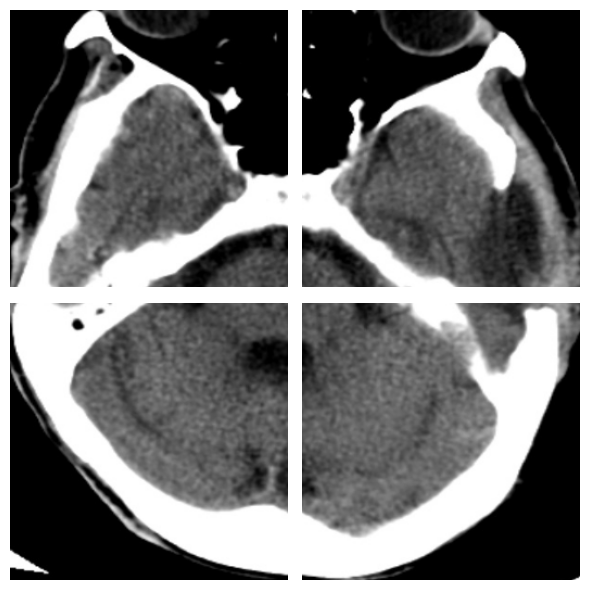

In [4]:
image=preprocessing(cv2.imread('Chronic/2428458 20.06.2013 chronic/01.jpeg'))
image=cv2.resize(image,(512,512))
image=cv2.merge((image,image,image))

p_image=patchify(image, (256,256,3), step=256)
p_image=np.reshape(p_image,(4,256,256,3))
                   
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
for i, ax in enumerate(axs.ravel()):
    ax.imshow(p_image[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

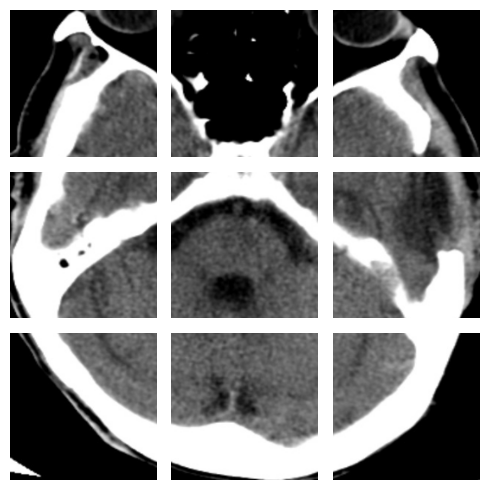

In [5]:
p_image=patchify(image, (170,170,3), step=170)
p_image=np.reshape(p_image,(9,170,170,3))
                   
fig, axs = plt.subplots(3, 3, figsize=(5, 5))
for i, ax in enumerate(axs.ravel()):
    ax.imshow(p_image[i])
    ax.axis('off')

plt.tight_layout()
plt.show()